In [233]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [234]:
df = pd.read_csv('exrx_exercises_muscles_with_body_part.csv')
print(df.columns, df.columns.shape)
df.head()

Index(['exercise_name', 'exercise_url', 'body_part', 'Target', 'Synergists',
       'Dynamic Stabilizers', 'Stabilizers', 'Antagonist Stabilizers',
       'Dynamic      Stabilizers', 'Target (see comments)',
       'Target (see comments)', 'Stabilizers (near arm)',
       'Stabilizers (far arm)', 'Antagonist      Stabilizers',
       'Target(See Comments)', 'Synergists (see comments)',
       'Target (See Comments)', 'Antagonist Stabilizers (see comments)',
       'Stabilizers (Raised Leg)', 'Stabilizers (Raised Arms)',
       'Stabilizers (see comments)', 'Stabilizers (raised leg)',
       'Stabilizers (raised arms)', 'Antagonist Stabilizers (see comment)',
       '​​​​​​​Stabilizers', 'Stabilizers (see comments)', 'Synergists (Neck)',
       'Synergists / Stabilizers (Spine)', 'Stabilizers (Other)',
       'Synergists (Spine)', 'Synergists / Stabilizers (Hips)'],
      dtype='str') (31,)


,exercise_name,exercise_url,body_part,Target,Synergists,Dynamic Stabilizers,Stabilizers,Antagonist Stabilizers,Dynamic Stabilizers,Target (see comments),...,Stabilizers (raised leg),Stabilizers (raised arms),Antagonist Stabilizers (see comment),​​​​​​​Stabilizers,Stabilizers (see comments),Synergists (Neck),Synergists / Stabilizers (Spine),Stabilizers (Other),Synergists (Spine),Synergists / Stabilizers (Hips)
0,Barbell Standing Leg Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,No significant stabilizers,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Cable Belt Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,No significant stabilizers,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Cable One Arm Single Leg Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,"Trapezius, Upper; Trapezius, Middle; Levator S...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Dumbbell Standing Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,"Trapezius, Upper; Trapezius, Middle; Levator S...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Dumbbell Single Leg Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,"Trapezius, Upper; Trapezius, Middle; Levator S...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [235]:
def intersects(columns: list[str]) -> bool:
    overlap = df[columns[0]].notna() & df[columns[1:]].notna().any(axis=1)
    return bool(overlap.any())


def merge_columns(columns: list[str], drop: bool = True, validate_no_overlap: bool = True) -> None:
    assert len(columns) > 1, "Must be more than one column"
    if validate_no_overlap and intersects(columns):
        raise ValueError(f"Intersection found in {columns}")

    filler = df[columns[1:]].bfill(axis=1).iloc[:, 0]
    df[columns[0]] = df[columns[0]].fillna(filler)

    if drop:
        df.drop(columns[1:], axis=1, inplace=True)

    print(f"Merged {columns} into {columns[0]}")

In [236]:
duplicates = [
    df.filter(like='Target').columns.to_list(),
    df.filter(like='Dynamic').columns.to_list(),
    df.filter(like='Antagonist').columns.to_list(),
    df.filter(like='Synergists').columns.to_list(),
]
print(sum([len(d) for d in duplicates]))
duplicates

17


[['Target',
  'Target\xa0(see comments)',
  'Target (see comments)',
  'Target(See Comments)',
  'Target (See Comments)'],
 ['Dynamic Stabilizers', 'Dynamic      Stabilizers'],
 ['Antagonist Stabilizers',
  'Antagonist      Stabilizers',
  'Antagonist Stabilizers (see comments)',
  'Antagonist Stabilizers (see comment)'],
 ['Synergists',
  'Synergists (see comments)',
  'Synergists (Neck)',
  'Synergists / Stabilizers (Spine)',
  'Synergists (Spine)',
  'Synergists / Stabilizers (Hips)']]

In [237]:
for duplicate_list in duplicates:
    merge_columns(duplicate_list)

Merged ['Target', 'Target\xa0(see comments)', 'Target (see comments)', 'Target(See Comments)', 'Target (See Comments)'] into Target
Merged ['Dynamic Stabilizers', 'Dynamic      Stabilizers'] into Dynamic Stabilizers
Merged ['Antagonist Stabilizers', 'Antagonist      Stabilizers', 'Antagonist Stabilizers (see comments)', 'Antagonist Stabilizers (see comment)'] into Antagonist Stabilizers
Merged ['Synergists', 'Synergists (see comments)', 'Synergists (Neck)', 'Synergists / Stabilizers (Spine)', 'Synergists (Spine)', 'Synergists / Stabilizers (Hips)'] into Synergists


In [238]:
def normalize_header(col: str) -> str:
    return col.replace("\u200b", "").strip()

stabilizers_duplicates = [
    col for col in df.columns if normalize_header(col).startswith("Stabilizers")
]

for col in stabilizers_duplicates:
    print(f"{col}: {df[col].count()}")
merge_columns(stabilizers_duplicates, validate_no_overlap=False)

Stabilizers: 576
Stabilizers (near arm): 1
Stabilizers (far arm): 1
Stabilizers (Raised Leg): 3
Stabilizers (Raised Arms): 2
Stabilizers (see comments): 1
Stabilizers (raised leg): 7
Stabilizers (raised arms): 2
​​​​​​​Stabilizers: 1
Stabilizers (see comments): 1
Stabilizers (Other): 2
Merged ['Stabilizers', 'Stabilizers (near arm)', 'Stabilizers (far arm)', 'Stabilizers (Raised Leg)', 'Stabilizers (Raised Arms)', 'Stabilizers\xa0(see comments)', 'Stabilizers (raised leg)', 'Stabilizers (raised arms)', '\u200b\u200b\u200b\u200b\u200b\u200b\u200bStabilizers', 'Stabilizers (see comments)', 'Stabilizers (Other)'] into Stabilizers


In [239]:
print(df.count())
df.head()

exercise_name             711
exercise_url              711
body_part                 711
Target                    703
Synergists                632
Dynamic Stabilizers       292
Stabilizers               582
Antagonist Stabilizers    167
dtype: int64


,exercise_name,exercise_url,body_part,Target,Synergists,Dynamic Stabilizers,Stabilizers,Antagonist Stabilizers
0,Barbell Standing Leg Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,No significant stabilizers,NaN
1,Cable Belt Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,No significant stabilizers,NaN
2,Cable One Arm Single Leg Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,"Trapezius, Upper; Trapezius, Middle; Levator S...",NaN
3,Dumbbell Standing Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,"Trapezius, Upper; Trapezius, Middle; Levator S...",NaN
4,Dumbbell Single Leg Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Calves,Gastrocnemius,Soleus,NaN,"Trapezius, Upper; Trapezius, Middle; Levator S...",NaN


In [240]:
def plot_topn(column_name: str, n: int = 15) -> None:
    df_exploded = df[column_name].dropna().str.split(';').explode().str.strip()
    df_exploded.value_counts().head(n).plot(kind='bar', figsize=(12, 6), rot=45)
    plt.title(f'Top {column_name} Muscles')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

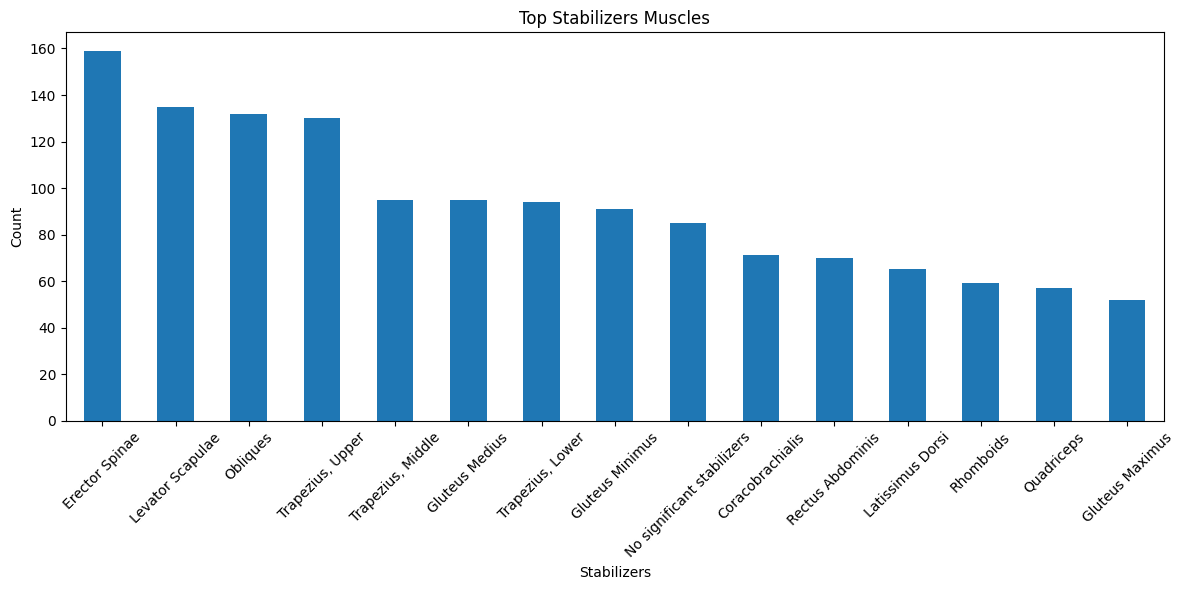

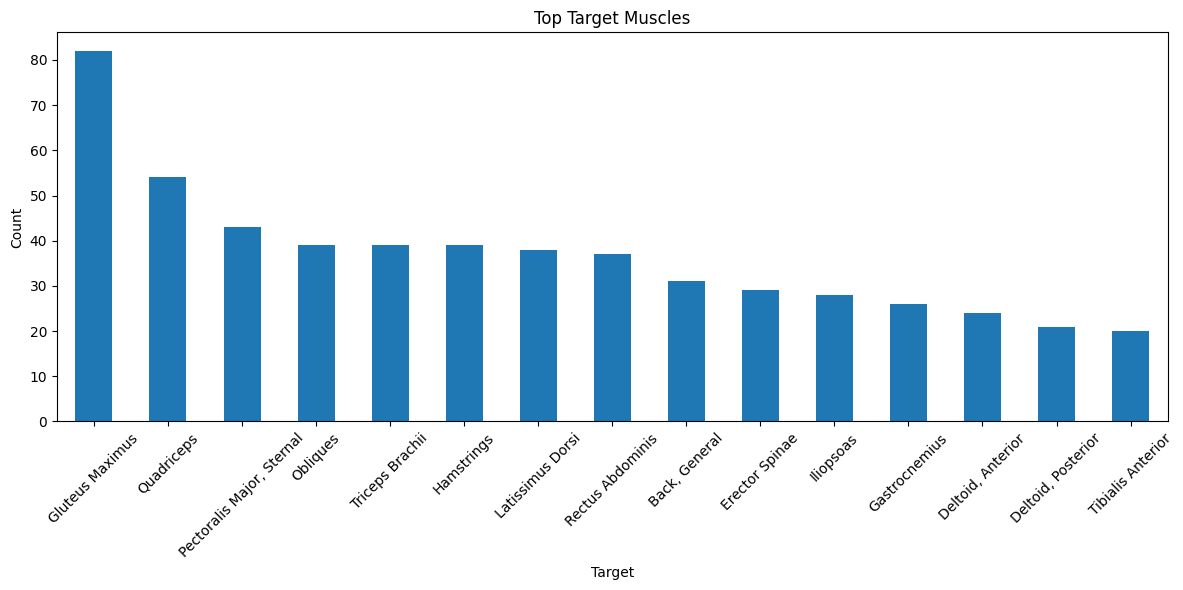

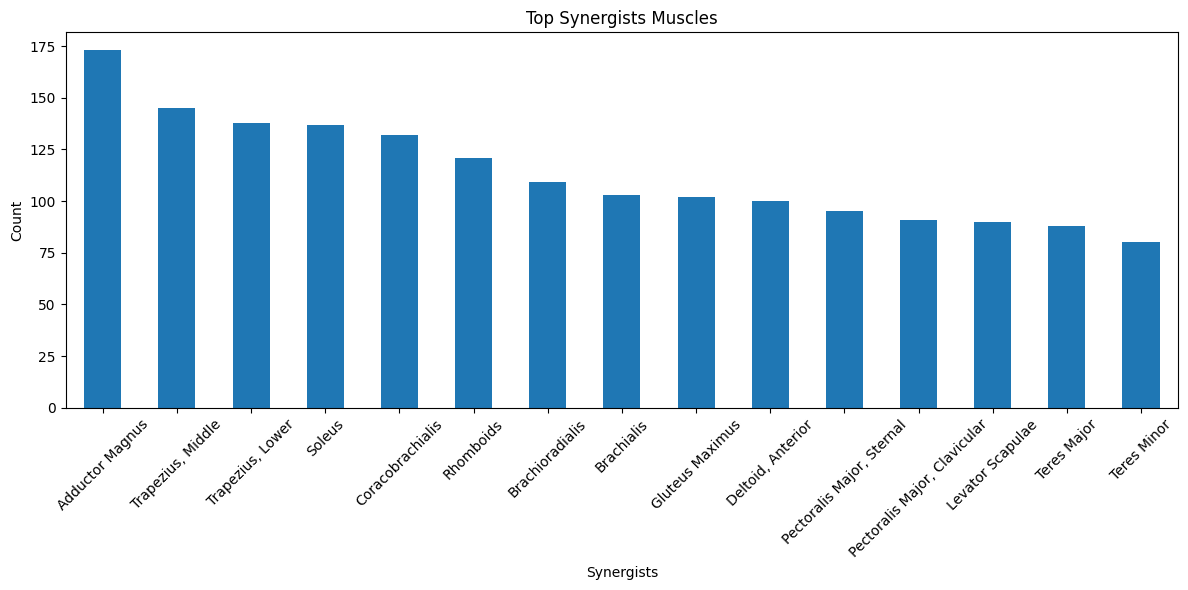

In [241]:
plot_topn('Stabilizers')
plot_topn('Target')
plot_topn('Synergists')

In [242]:
role_cols = [
    c
    for c in ["Target", "Synergists", "Dynamic Stabilizers", "Stabilizers", "Antagonist Stabilizers"]
    if c in df.columns
]

tidy_df = (
    df.melt(
        id_vars=["exercise_name", "exercise_url"],
        value_vars=role_cols,
        var_name="role",
        value_name="muscles_raw",
    )
    .dropna(subset=["muscles_raw"])
    .assign(muscle=lambda x: x["muscles_raw"].str.split(";"))
    .explode("muscle")
    .assign(muscle=lambda x: x["muscle"].str.strip())
    .query("muscle != ''")
    .drop(columns=["muscles_raw"])
    .reset_index(drop=True)
)

print("Original rows:", len(df))
print("Long-format rows:", len(tidy_df))
tidy_df.head()

Original rows: 711
Long-format rows: 6620


,exercise_name,exercise_url,role,muscle
0,Barbell Standing Leg Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Target,Gastrocnemius
1,Cable Belt Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Target,Gastrocnemius
2,Cable One Arm Single Leg Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Target,Gastrocnemius
3,Dumbbell Standing Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Target,Gastrocnemius
4,Dumbbell Single Leg Calf Raise,https://exrx.net/WeightExercises/Gastrocnemius...,Target,Gastrocnemius


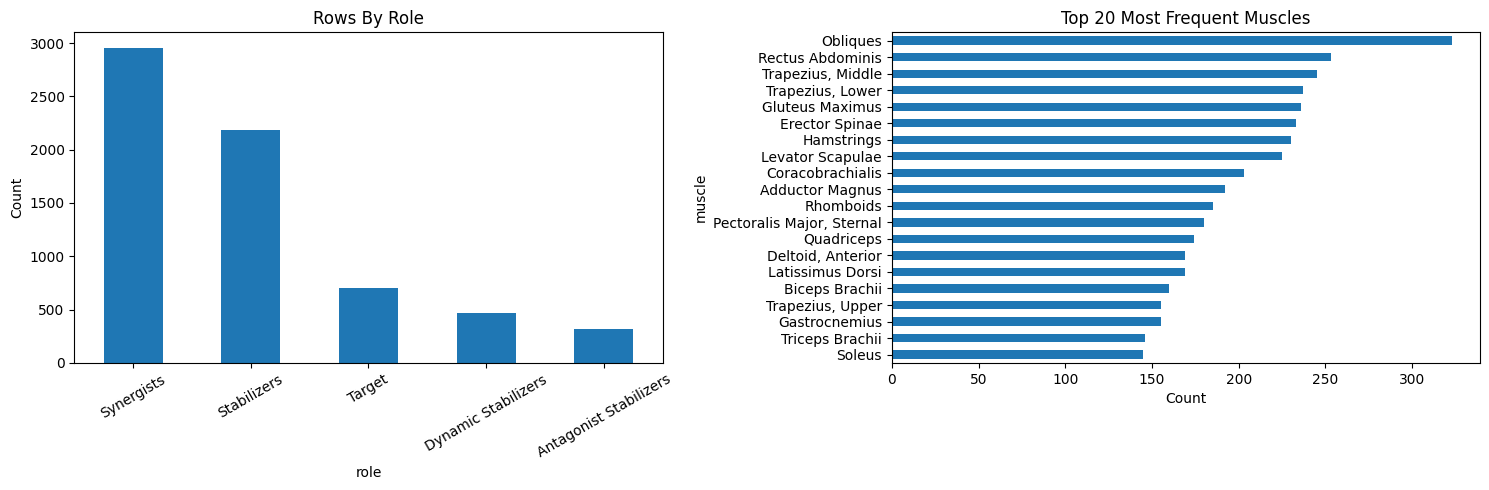

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tidy_df["role"].value_counts().plot(kind="bar", ax=axes[0], rot=30, title="Rows By Role")
axes[0].set_ylabel("Count")

tidy_df["muscle"].value_counts().head(20).sort_values().plot(
    kind="barh", ax=axes[1], title="Top 20 Most Frequent Muscles"
)
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

In [244]:
pairs = (
    tidy_df[tidy_df["role"] == "Target"][["exercise_url", "muscle"]]
    .rename(columns={"muscle": "target_muscle"})
    .merge(
        tidy_df[tidy_df["role"].isin(["Synergists", "Stabilizers"])][["exercise_url", "role", "muscle"]]
        .rename(columns={"muscle": "support_muscle", "role": "support_role"}),
        on="exercise_url",
        how="inner",
    )
)

pair_counts = (
    pairs.groupby(["target_muscle", "support_role", "support_muscle"])
    .size()
    .reset_index(name="exercise_count")
    .sort_values("exercise_count", ascending=False)
)

pair_counts.head(20)

,target_muscle,support_role,support_muscle,exercise_count
263,Gluteus Maximus,Synergists,Adductor Magnus,76
272,Gluteus Maximus,Synergists,Quadriceps,59
239,Gluteus Maximus,Stabilizers,Erector Spinae,58
273,Gluteus Maximus,Synergists,Soleus,55
577,Quadriceps,Synergists,Adductor Magnus,53
583,Quadriceps,Synergists,Soleus,53
582,Quadriceps,Synergists,Gluteus Maximus,53
546,"Pectoralis Major, Sternal",Synergists,"Pectoralis Major, Clavicular",42
541,"Pectoralis Major, Sternal",Synergists,Coracobrachialis,42
243,Gluteus Maximus,Stabilizers,Gluteus Minimus,41


In [245]:
out_path = "exrx_exercises_muscles_clean.csv"
df.to_csv(out_path, index=False)